# Exploratory Data Analysis
## Enterprise Predictive Analytics Engine — E-commerce Domain

**Objective:** Explore the cleaned dataset before any modeling — understand
distributions, trends, outliers, and relationships between variables.
Findings from this notebook directly inform the feature engineering and
modeling decisions made in the clustering, classification, and forecasting
notebooks that follow.

**Input:** `data/processed/olist_master_cleaned.csv`
**Output:** EDA charts saved to `outputs/figures/`

**Steps:**
1. Load cleaned data
2. Order volume & revenue trends over time
3. Category-level analysis
4. Geographic distribution
5. Delivery performance analysis
6. Review score distribution
7. Correlation analysis
8. Key takeaways → modeling implications

## 1. Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("../data/processed/olist_master_cleaned.csv", parse_dates=["order_purchase_timestamp"])
print("Shape:", df.shape)
df.info()

Shape: (113425, 27)
<class 'pandas.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 27 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       113425 non-null  str           
 1   customer_id                    113425 non-null  str           
 2   order_status                   113425 non-null  str           
 3   order_purchase_timestamp       113425 non-null  datetime64[us]
 4   order_approved_at              113264 non-null  str           
 5   order_delivered_carrier_date   111457 non-null  str           
 6   order_delivered_customer_date  110196 non-null  str           
 7   order_estimated_delivery_date  113425 non-null  str           
 8   customer_unique_id             113425 non-null  str           
 9   customer_zip_code_prefix       113425 non-null  int64         
 10  customer_city                  113425 non-null  str        

## 2. Order Volume & Revenue Trends Over Time

Visualizing how order volume and revenue evolved month-over-month —
important to see *before* forecasting, so seasonality and data cutoffs
are identified upfront rather than discovered mid-modeling.

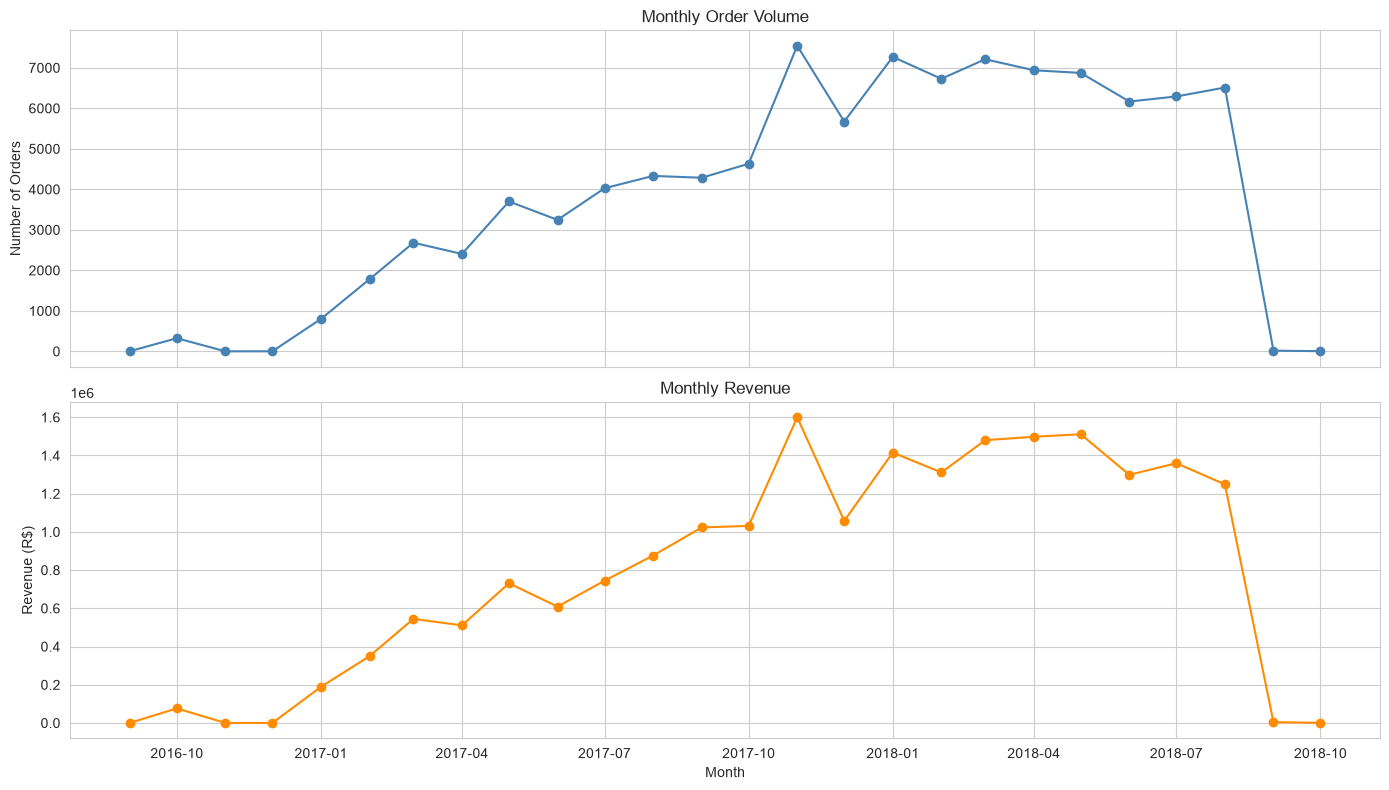

In [2]:
monthly_trends = (
    df.set_index("order_purchase_timestamp")
    .resample("MS")
    .agg(order_count=("order_id", "nunique"), revenue=("payment_value", "sum"))
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(monthly_trends["order_purchase_timestamp"], monthly_trends["order_count"], marker="o", color="steelblue")
axes[0].set_title("Monthly Order Volume")
axes[0].set_ylabel("Number of Orders")

axes[1].plot(monthly_trends["order_purchase_timestamp"], monthly_trends["revenue"], marker="o", color="darkorange")
axes[1].set_title("Monthly Revenue")
axes[1].set_ylabel("Revenue (R$)")
axes[1].set_xlabel("Month")

plt.tight_layout()
plt.savefig("../outputs/figures/eda_monthly_trends.png", dpi=100, bbox_inches="tight")
plt.show()

### Modeling Implication (Forecasting)

Two things to account for when building the forecasting model later:
1. **Trim Sept-Dec 2016** — unstable launch period, not representative demand
2. **Verify the actual end of the dataset** before assuming the last visible
   month is complete — the sharp drop after Aug 2018 suggests the data
   collection window ends there, not a real demand crash. We'll confirm
   this with order counts before choosing a forecast cutoff.

## 3. Category-Level Analysis

Examining which product categories drive the most revenue and order
volume — this may inform whether category should be included as a
feature in the classification model.

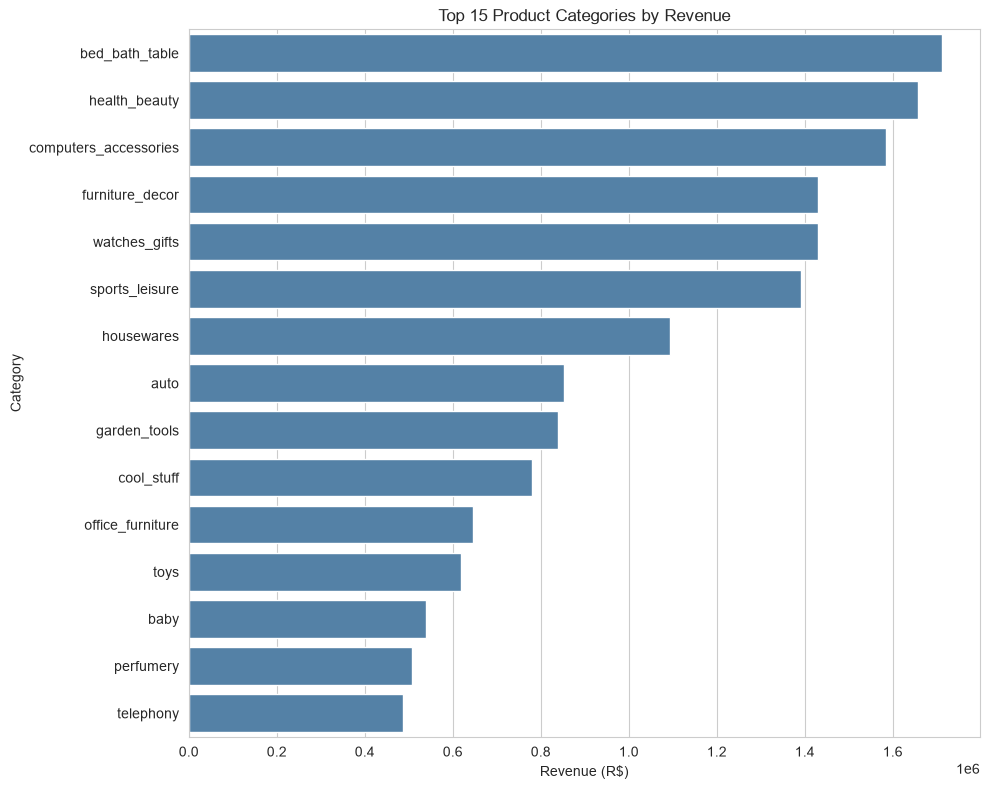

,product_category_name_english,order_count,revenue
0,bed_bath_table,9417,1712553.67
1,health_beauty,8836,1657373.12
2,computers_accessories,6689,1585330.45
3,furniture_decor,6449,1430176.39
4,watches_gifts,5624,1429216.68
5,sports_leisure,7720,1392127.56
6,housewares,5884,1094758.13
7,auto,3897,852294.33
8,garden_tools,3518,838280.75
9,cool_stuff,3632,779698.00


In [3]:
category_stats = (
    df.groupby("product_category_name_english")
    .agg(order_count=("order_id", "nunique"), revenue=("payment_value", "sum"))
    .sort_values("revenue", ascending=False)
    .head(15)
    .reset_index()
)

plt.figure(figsize=(10, 8))
sns.barplot(data=category_stats, x="revenue", y="product_category_name_english", color="steelblue")
plt.title("Top 15 Product Categories by Revenue")
plt.xlabel("Revenue (R$)")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig("../outputs/figures/eda_top_categories.png", dpi=100, bbox_inches="tight")
plt.show()

category_stats

## 4. Geographic Distribution

Examining which Brazilian states generate the most orders and revenue.

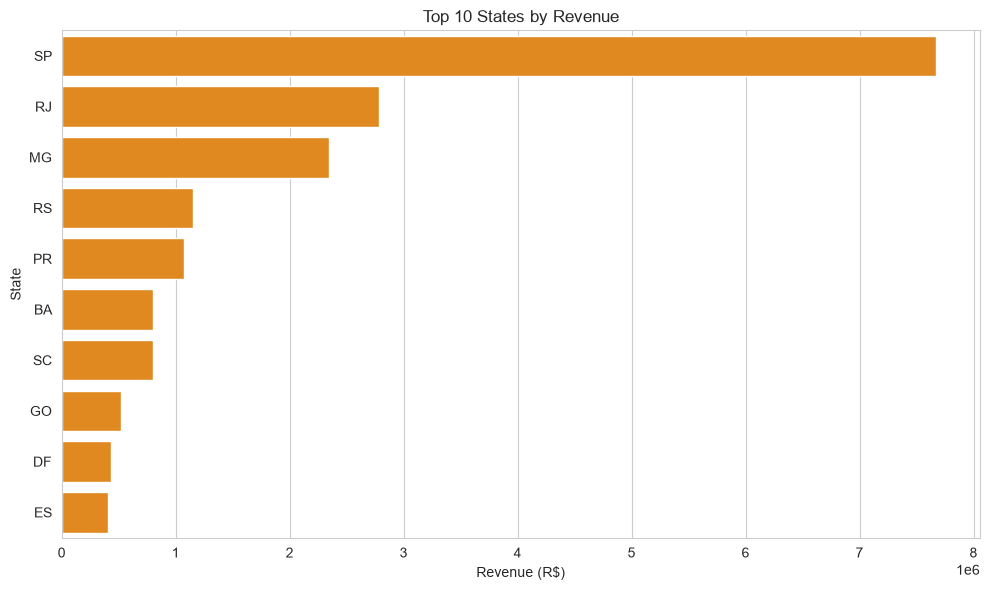

,customer_state,order_count,revenue
0,SP,41746,7673188.55
1,RJ,12852,2783724.26
2,MG,11635,2341861.47
3,RS,5466,1152019.17
4,PR,5045,1074614.19
5,BA,3380,802416.72
6,SC,3637,799135.92
7,GO,2020,516182.51
8,DF,2140,434512.55
9,ES,2033,406946.26


In [4]:
state_stats = (
    df.groupby("customer_state")
    .agg(order_count=("order_id", "nunique"), revenue=("payment_value", "sum"))
    .sort_values("revenue", ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=state_stats, x="revenue", y="customer_state", color="darkorange")
plt.title("Top 10 States by Revenue")
plt.xlabel("Revenue (R$)")
plt.ylabel("State")
plt.tight_layout()
plt.savefig("../outputs/figures/eda_top_states.png", dpi=100, bbox_inches="tight")
plt.show()

state_stats

## 5. Delivery Performance Analysis

Examining delivery time and delay patterns — this will directly inform
which features to prioritize in the classification model.

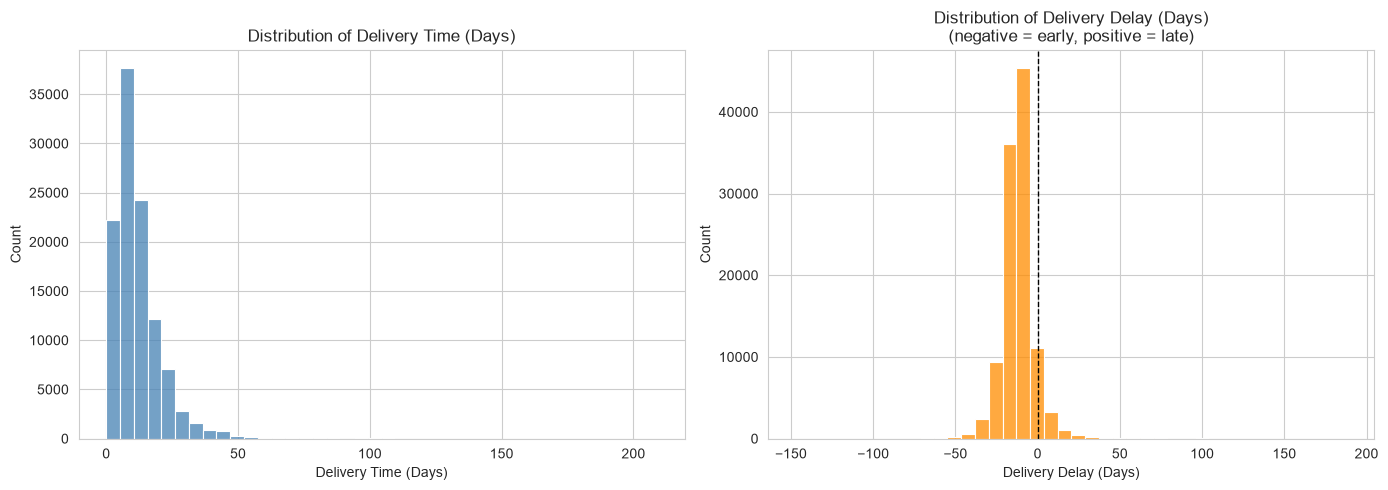

Delivery time - median: 10 days, 95th percentile: 29 days
Orders delivered late: 6.59%


In [5]:
delivered = df[df["is_delivered"] == True].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(delivered["delivery_time_days"], bins=40, color="steelblue", ax=axes[0])
axes[0].set_title("Distribution of Delivery Time (Days)")
axes[0].set_xlabel("Delivery Time (Days)")

sns.histplot(delivered["delivery_delay_days"], bins=40, color="darkorange", ax=axes[1])
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Distribution of Delivery Delay (Days)\n(negative = early, positive = late)")
axes[1].set_xlabel("Delivery Delay (Days)")

plt.tight_layout()
plt.savefig("../outputs/figures/eda_delivery_performance.png", dpi=100, bbox_inches="tight")
plt.show()

print("Delivery time - median: {:.0f} days, 95th percentile: {:.0f} days".format(
    delivered["delivery_time_days"].median(), delivered["delivery_time_days"].quantile(0.95)))
print("Orders delivered late: {:.2%}".format((delivered["delivery_delay_days"] > 0).mean()))

## 6. Review Score Distribution

Understanding the class balance for review scores — this directly
determines how we'll handle class imbalance in the classification model.

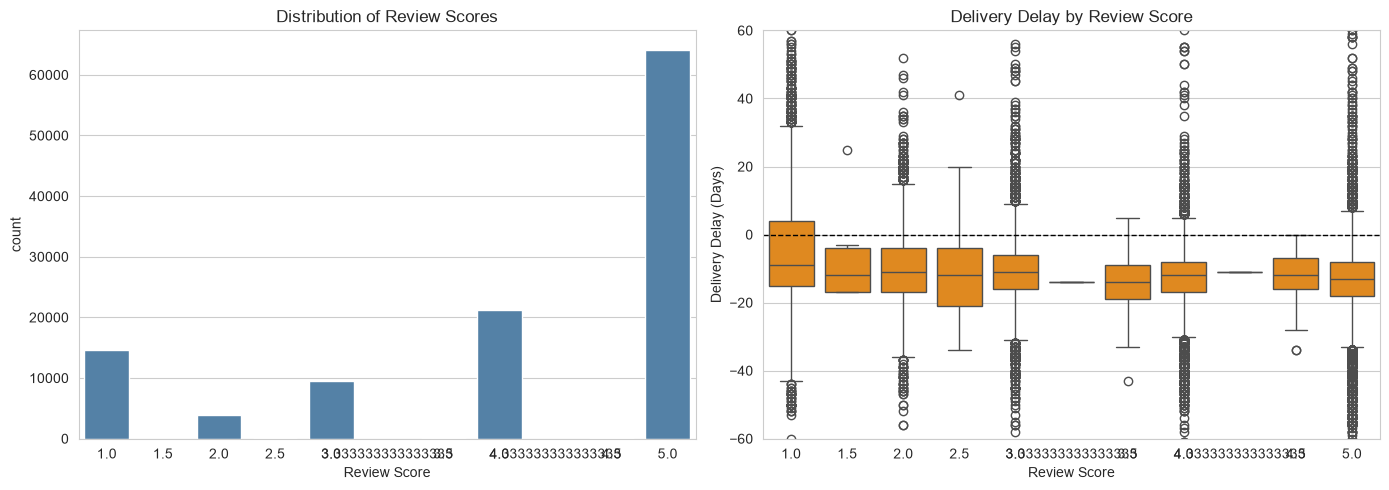

review_score
1.000000    0.129
1.500000    0.000
2.000000    0.034
2.500000    0.000
3.000000    0.083
3.333333    0.000
3.500000    0.000
4.000000    0.187
4.333333    0.000
4.500000    0.001
5.000000    0.565
Name: proportion, dtype: float64

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="review_score", color="steelblue", ax=axes[0])
axes[0].set_title("Distribution of Review Scores")
axes[0].set_xlabel("Review Score")

sns.boxplot(data=delivered, x="review_score", y="delivery_delay_days", color="darkorange", ax=axes[1])
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Delivery Delay by Review Score")
axes[1].set_xlabel("Review Score")
axes[1].set_ylabel("Delivery Delay (Days)")
axes[1].set_ylim(-60, 60)

plt.tight_layout()
plt.savefig("../outputs/figures/eda_review_scores.png", dpi=100, bbox_inches="tight")
plt.show()

df["review_score"].value_counts(normalize=True).sort_index().round(3)

## 7. Correlation Analysis

Examining relationships between key numeric variables — this is the
step that most directly shapes our classification model's feature
choices, done here *before* modeling rather than after.

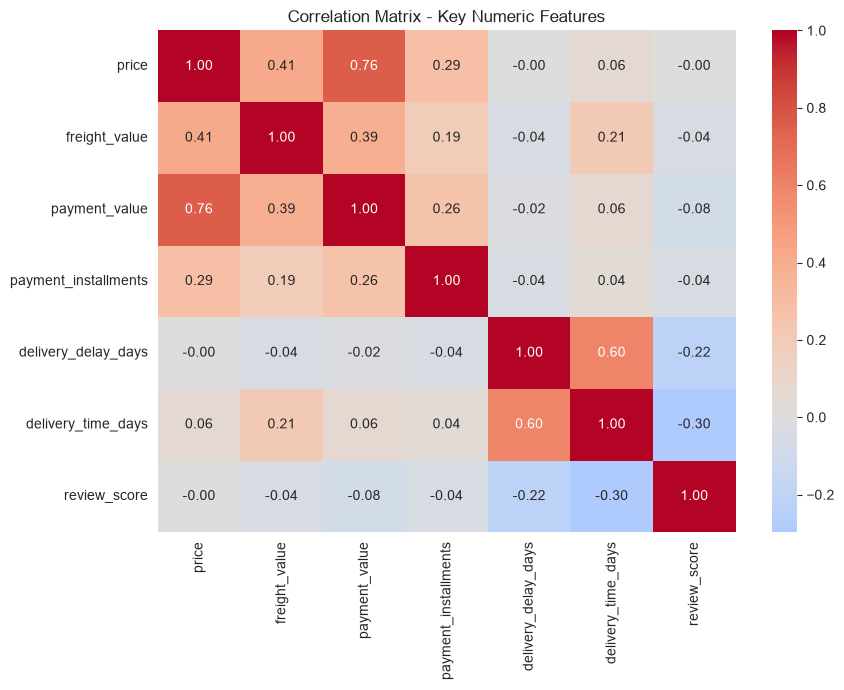

In [7]:
corr_cols = ["price", "freight_value", "payment_value", "payment_installments",
             "delivery_delay_days", "delivery_time_days", "review_score"]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix - Key Numeric Features")
plt.tight_layout()
plt.savefig("../outputs/figures/eda_correlation_matrix.png", dpi=100, bbox_inches="tight")
plt.show()

## 8. Key Takeaways & Modeling Implications

**Business trends:**
- Order volume and revenue grew steadily from Jan 2017 through mid-2018,
  with a clear Black Friday spike in November 2017
- Data collection ends around August 2018

**Category & geography:**
- Bed/bath/table and health/beauty are the top revenue-driving categories
- São Paulo (SP) alone generates ~35% of total revenue — heavy geographic
  concentration

**Delivery & satisfaction:**
- Only 6.59% of orders are delivered late; median delivery time is 10 days
- Delivery timing shows the strongest correlation with review score
  (delivery_time_days: -0.30, delivery_delay_days: -0.22) — far stronger
  than price, freight, or payment installments (all near 0)

**Review scores:**
- 56.5% of reviews are 5-star; ~16.3% are low (≤2)

---

### How this shapes the next three notebooks:

**03_clustering_segmentation.ipynb**
- RFM (Recency, Frequency, Monetary) remains the right approach —
  category and geography don't show strong enough segment-defining signal
  here to justify adding them to the clustering feature set
- Expect most customers to be one-time buyers (median frequency ~1),
  confirmed independently in this EDA

**04_classification_churn.ipynb**
- Given the correlation analysis, `delivery_delay_days` and
  `delivery_time_days` should be treated as the primary predictive
  features, not just included alongside others
- Price/freight/payment features are unlikely to add much signal —
  worth including for completeness, but expectations should be set
  accordingly
- Class imbalance (~16% low reviews) confirmed — use `class_weight="balanced"`
- Given category showed real revenue concentration (top 15 categories),
  keep category as a feature — it may still capture product-specific
  quality/expectation patterns not visible in aggregate correlation

**05_forecasting_revenue.ipynb**
- Confirmed: trim Sept-Dec 2016 (unstable launch period) before forecasting
- Confirmed: data ends ~Aug 2018 — verify order counts near the cutoff
  before trusting the last visible month, rather than assuming it's complete
- Given only ~20 months of clean data, yearly seasonality should likely be
  disabled in Prophet to avoid overfitting — decided here proactively,
  not reactively after seeing a bad forecast

**Next notebook:** `03_clustering_segmentation.ipynb`